# Totais do corpus (72 listas)

In [1]:
import glob
import os

import pandas as pd

BUILD_THREADS_DIR = '../build_threads_output'

files = sorted(glob.glob(os.path.join(BUILD_THREADS_DIR, 'list_data_*.parquet')))

per_list = pd.DataFrame(
    [
        {
            'list': os.path.basename(path).removeprefix('list_data_').removesuffix('.parquet'),
            'threads': len(df),
            'emails': int(df['n_messages'].sum()),
        }
        for path, df in ((path, pd.read_parquet(path, columns=['n_messages'])) for path in files)
    ]
)

overall = pd.DataFrame({
    'metric': ['total_lists', 'total_emails', 'total_threads'],
    'value': [len(per_list), per_list['emails'].sum(), per_list['threads'].sum()],
})
overall

,metric,value
0,total_lists,72
1,total_emails,3521123
2,total_threads,670211


# Por lista

In [2]:
per_list.sort_values('emails', ascending=False).reset_index(drop=True)

,list,threads,emails
0,netdev,216279,1229125
1,linux-fsdevel,43907,352187
2,bpf,23203,188884
3,amd,27141,146423
4,linux-kselftest,15948,123143
...,...,...,...
67,opae,40,70
68,lch,13,41
69,printing-users,14,40
70,mailbox,7,26


# Termos da regex do pré-filtro

In [3]:
import sys

sys.path.insert(0, '..')
from pre_filter.pre_filter_threads import CANDIDATE_RE


def top_level_alternatives(pattern):
    body = pattern.removeprefix(r'\b(?:').removesuffix(r')\b')
    parts, depth, current = [], 0, ''
    for char in body:
        if char == '(':
            depth += 1
        elif char == ')':
            depth -= 1
        if char == '|' and depth == 0:
            parts.append(current)
            current = ''
        else:
            current += char
    return parts + [current]


pd.DataFrame({'pattern': top_level_alternatives(CANDIDATE_RE.pattern)})

,pattern
0,duplicat[a-z]*
1,dedup[a-z]*
2,redundant[a-z]*
3,repeated
4,copy[-_\s]?past(?:e|ed|ing)


# Resultados do pré-filtro

In [4]:
PRE_FILTER_DIR = '../pre_filter/pre_filter_output'

pre_filter_files = sorted(glob.glob(os.path.join(PRE_FILTER_DIR, 'list_data_*.parquet')))

candidates = pd.DataFrame(
    [
        {
            'list': os.path.basename(path).removeprefix('list_data_').removesuffix('.parquet'),
            'candidate_threads': len(df),
            'candidate_emails': int(df['n_messages'].sum()),
        }
        for path, df in ((path, pd.read_parquet(path, columns=['n_messages'])) for path in pre_filter_files)
    ]
)

pre_filter = per_list.merge(candidates, on='list')
pre_filter['selection_rate'] = (pre_filter['candidate_threads'] / pre_filter['threads']).round(3)

pd.DataFrame(
    {
        'metric': ['total_candidate_emails', 'total_candidate_threads', 'selection_rate'],
        'value': [
            pre_filter['candidate_emails'].sum(),
            pre_filter['candidate_threads'].sum(),
            round(pre_filter['candidate_threads'].sum() / pre_filter['threads'].sum(), 3),
        ],
    },
    dtype=object,
)

,metric,value
0,total_candidate_emails,895193
1,total_candidate_threads,66189
2,selection_rate,0.099


# Resultados do pré-filtro por lista

In [5]:
pre_filter[['list', 'emails', 'threads', 'candidate_emails', 'candidate_threads', 'selection_rate']].sort_values(
    'candidate_threads', ascending=False
).reset_index(drop=True)

,list,emails,threads,candidate_emails,candidate_threads,selection_rate
0,netdev,1229125,216279,276275,22204,0.103
1,linux-fsdevel,352187,43907,131513,7203,0.164
2,linux-next,86362,35196,13823,4905,0.139
3,bpf,188884,23203,61533,3903,0.168
4,linux-kselftest,123143,15948,44355,2537,0.159
...,...,...,...,...,...,...
67,printing-users,40,14,16,1,0.071
68,lch,41,13,0,0,0.000
69,mailbox,26,7,0,0,0.000
70,lvfs-general,14,9,0,0,0.000


# Threads por termo encontrado

In [6]:
matched_terms = pd.concat(
    [pd.read_parquet(path, columns=['matched_terms'])['matched_terms'] for path in pre_filter_files],
    ignore_index=True,
)

per_term_threads = matched_terms.str.split(',').explode().value_counts().rename('threads').to_frame()
per_term_threads['share_of_candidates'] = (per_term_threads['threads'] / len(matched_terms)).round(3)
per_term_threads

,threads,share_of_candidates
matched_terms,,
duplicate,25011,0.378
redundant,22937,0.347
duplicated,10204,0.154
duplication,7945,0.120
repeated,5681,0.086
...,...,...
duplicatign,1,0.000
dedupplicate,1,0.000
duplicateerror,1,0.000


# Taxa de verdadeiros e falsos positivos por termo encontrado

In [7]:
CONSOLIDATED = 'consolidated/sample_review_all_consolidated_quotes_removed.csv'

reviewed = pd.read_csv(CONSOLIDATED, dtype=str, keep_default_na=False)
# matched_terms is what the current pre-filter matches in the stored content
# (quoted replies already replaced). Threads it no longer matches drop out.
matched = reviewed[reviewed['matched_terms'] != ''].copy()
matched['term'] = matched['matched_terms'].str.split(',')

per_term = (
    matched.explode('term')
    .groupby('term')['final_decision']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns={'yes': 'true_positives', 'no': 'false_positives'})
)
per_term['threads'] = per_term['true_positives'] + per_term['false_positives']

summary = pd.DataFrame({
    'threads': per_term['threads'],
    'true_positives (%)': (100 * per_term['true_positives'] / per_term['threads']).round(1),
    'false_positives (%)': (100 * per_term['false_positives'] / per_term['threads']).round(1),
})

summary.loc[per_term.sort_values(['true_positives', 'threads'], ascending=False).index].rename_axis('term').reset_index()

,term,threads,true_positives (%),false_positives (%)
0,duplication,46,91.3,8.7
1,duplicate,55,36.4,63.6
2,common-helper,26,76.9,23.1
3,redundant,73,24.7,75.3
4,duplicated,29,62.1,37.9
5,deduplicate,15,93.3,6.7
6,duplicating,13,92.3,7.7
7,repeated,21,47.6,52.4
8,duplicates,17,35.3,64.7
9,copy-pasted,6,100.0,0.0


# Melhorias

- O pré-filtro agora substitui as citações de respostas no `thread_content` por `[quoted text removed]`: citações no estilo Gmail (linhas com `>`) e no estilo Outlook (cabeçalhos `From:`/`Sent:` ou `-----Original Message-----`).
- O sample foi rotulado por dois revisores, de forma independente.
- Concordância em yes/no: 293 de 324 threads (90,4%), kappa de Cohen 0,80.
- Categorias e um exemplo de cada:
  - `clone_refactoring`: "moving the core logic into a generic function inside amdgpu_gfx.c to reduce code duplication"
  - `preventive_reuse`: "GENI_IF_DISABLE_RO is used by geni spi driver as well [...] so move this to common header qcom-geni-se.h"
  - `duplication_discussion`: "if this just duplicates the cdc-acm interface [...] I don't think you need a kernel driver at all for it."
  - `satd`: "The original definitions were duplicated to reduce tree churn during introduction of chan_spec registration. Now there is no point in maintaining the two sets of definitions."
  - `not_duplication`: "[PATCH v1] i2c: img-scb: remove duplicate dev_err()" — "it will print an error message by itself when platform_get_irq() goes wrong. so don't need dev_err() in here again."

# Resultados dos classificadores de IA

- Jev (TypeSafe): modelo "System One", feito para tomar decisões estruturadas que o código usa diretamente, em vez de gerar texto. Recebe um estado (a thread) e perguntas tipadas, e devolve valores e distribuições de probabilidade, sem geração de texto nem parsing da resposta.
- GPT (`gpt-5.4-nano`): uma chamada por thread, com os critérios de rotulação no prompt, seis exemplos (few-shot) e um raciocínio curto (chain of thought, até 100 palavras) antes das categorias.
- Jev `noul`: uma pergunta de sim/não por categoria (nota de 0 a 1), com critérios do que a torna verdadeira ou falsa; a categoria vale a partir de 0,5.
- Jev `choice`: uma única pergunta que escolhe a categoria principal entre opções exclusivas, mais a pergunta `noul` de `satd`, já que `satd` pode aparecer junto com qualquer categoria.
- OpenJev `choice`: alternativa open source ao Jev, com as mesmas perguntas do Jev `choice`, respondidas por modelos de pesos abertos via OpenRouter (`qwen/qwen3-235b-a22b-2507` e `deepseek/deepseek-v4-flash`); as probabilidades vêm dos logprobs do primeiro token da resposta, com uma chamada por pergunta.
- Laya: também foi testado, mas a janela de contexto é muito curta.

Exemplo de requisição ao Jev (documentação da TypeSafe):

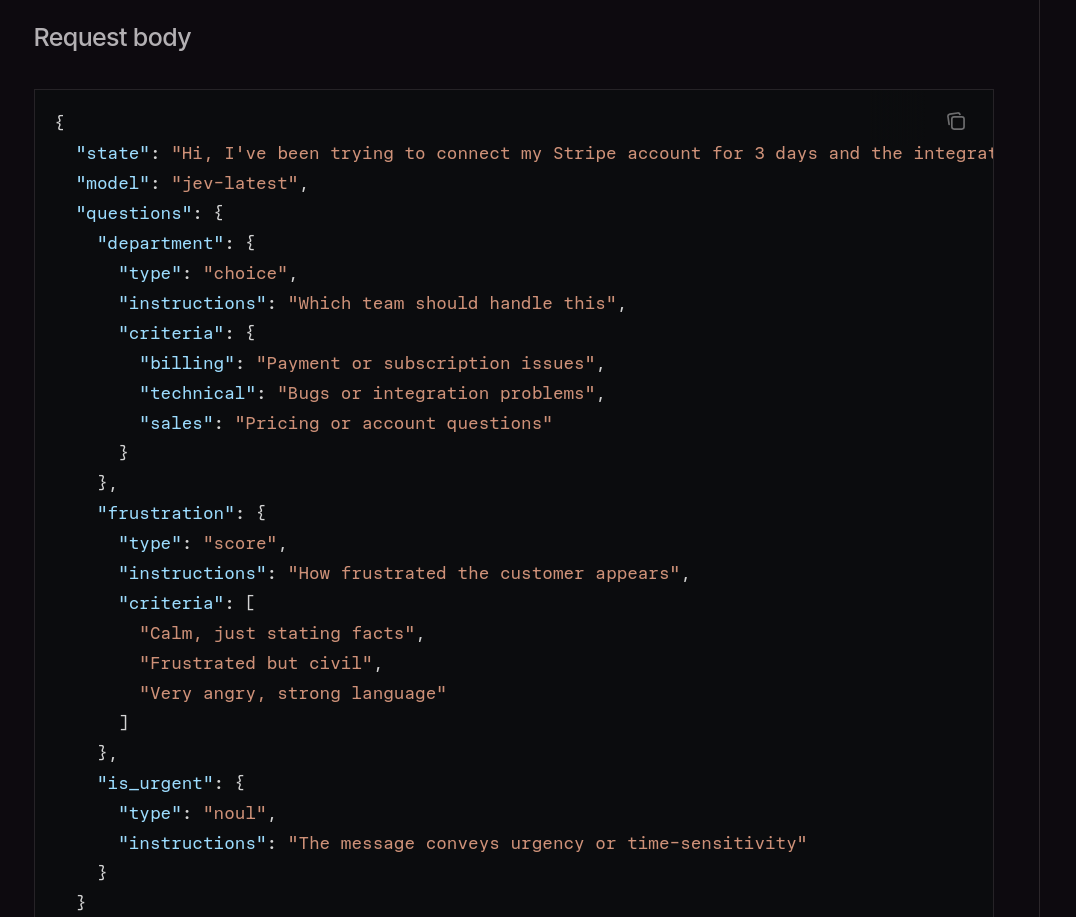

In [8]:
import json

EVALUATION_DIR = '../classify/evaluation_output'
CLASSIFIER_OUTPUTS = {
    'openai': os.path.join(EVALUATION_DIR, 'openai', 'sample.csv'),
    'jev-noul': os.path.join(EVALUATION_DIR, 'jev', 'noul', 'sample.csv'),
    'jev-choice': os.path.join(EVALUATION_DIR, 'jev', 'choice', 'sample.csv'),
    'openjev-qwen-choice': os.path.join(EVALUATION_DIR, 'openjev', 'choice', 'sample.csv'),
    'openjev-deepseek-choice': os.path.join(EVALUATION_DIR, 'openjev-deepseek-v4-flash', 'choice', 'sample.csv'),
}

labelled = reviewed.loc[reviewed['final_decision'] != '', ['thread_id', 'final_decision', 'category']]

# Threads each classifier ran on, which the time and cost runs below refer to.
classified_threads = len(pd.read_csv(CLASSIFIER_OUTPUTS['openai'], usecols=['thread_id']))


def answers(path):
    results = pd.read_csv(path, dtype=str, keep_default_na=False)[['thread_id', 'llm_categories']]
    merged = labelled.merge(results, on='thread_id', how='inner', validate='one_to_one')
    predicted = merged['llm_categories'].map(lambda value: ','.join(json.loads(value)) if value else '')
    predicted_decision = predicted.map(lambda value: 'no' if value == 'not_duplication' else 'yes')
    merged['category_result'] = (predicted == merged['category']).map({True: 'correct', False: 'wrong'})
    merged['decision_result'] = (predicted_decision == merged['final_decision']).map({True: 'correct', False: 'wrong'})
    merged.loc[predicted == '', ['category_result', 'decision_result']] = 'failed'
    return merged


def result_table(by, result_column):
    tables = {}
    for name, path in CLASSIFIER_OUTPUTS.items():
        merged = answers(path)
        counts = pd.crosstab(merged[by], merged[result_column], margins=True, margins_name='total')
        counts = counts.reindex(columns=['correct', 'failed', 'total'], fill_value=0)
        tables[name] = pd.DataFrame({
            result: [
                f'{count} ({100 * count / total:.1f}%)'
                for count, total in zip(counts[result], counts['total'])
            ]
            for result in ['correct', 'failed']
        }, index=counts.index)
    return pd.concat(tables, axis=1)


# Resultados por categoria

In [9]:
result_table('category', 'category_result')

openai               jev-noul  \
                                        correct    failed      correct   
category                                                                 
clone_refactoring                    42 (80.8%)  0 (0.0%)     0 (0.0%)   
clone_refactoring,preventive_reuse     0 (0.0%)  0 (0.0%)    4 (80.0%)   
clone_refactoring,satd                 0 (0.0%)  0 (0.0%)     0 (0.0%)   
duplication_discussion                9 (42.9%)  0 (0.0%)   11 (52.4%)   
not_duplication                     179 (86.1%)  0 (0.0%)  150 (72.1%)   
preventive_reuse                      4 (28.6%)  0 (0.0%)    7 (50.0%)   
total                               234 (77.0%)  0 (0.0%)  172 (56.6%)   

                                               jev-choice            \
                                      failed      correct    failed   
category                                                              
clone_refactoring                   0 (0.0%)   43 (82.7%)  0 (0.0%)   
clone_refactoring,preventive_reuse  0 (0.0%)    1 (20.0%)  0 (0.0%)   
clone_refactoring,satd              0 (0.0%)   4 (100.0%)  0 (0.0%)   
duplication_discussion              0 (0.0%)   13 (61.9%)  0 (0.0%)   
not_duplication                     0 (0.0%)  169 (81.2%)  0 (0.0%)   
preventive_reuse                    0 (0.0%)    8 (57.1%)  1 (7.1%)   
total                               0 (0.0%)  238 (78.3%)  1 (0.3%)   

                                   openjev-qwen-choice            \
                                               correct    failed   
category                                                           
clone_refactoring                           21 (40.4%)  0 (0.0%)   
clone_refactoring,preventive_reuse           2 (40.0%)  0 (0.0%)   
clone_refactoring,satd                        0 (0.0%)  0 (0.0%)   
duplication_discussion                        0 (0.0%)  0 (0.0%)   
not_duplication                            195 (93.8%)  0 (0.0%)   
preventive_reuse                             4 (28.6%)  0 (0.0%)   
total                                      222 (73.0%)  0 (0.0%)   

                                   openjev-deepseek-choice            
                                                   correct    failed  
category                                                              
clone_refactoring                               13 (25.0%)  0 (0.0%)  
clone_refactoring,preventive_reuse               3 (60.0%)  0 (0.0%)  
clone_refactoring,satd                            0 (0.0%)  0 (0.0%)  
duplication_discussion                           8 (38.1%)  0 (0.0%)  
not_duplication                                   0 (0.0%)  0 (0.0%)  
preventive_reuse                                  0 (0.0%)  0 (0.0%)  
total                                            24 (7.9%)  0 (0.0%)

# Resultados por yes/no

In [10]:
result_table('final_decision', 'decision_result')

openai               jev-noul             jev-choice  \
                    correct    failed      correct    failed      correct   
final_decision                                                              
no              179 (86.1%)  0 (0.0%)  150 (72.1%)  0 (0.0%)  169 (81.2%)   
yes              72 (75.0%)  0 (0.0%)   91 (94.8%)  0 (0.0%)   91 (94.8%)   
total           251 (82.6%)  0 (0.0%)  241 (79.3%)  0 (0.0%)  260 (85.5%)   

                         openjev-qwen-choice            \
                  failed             correct    failed   
final_decision                                           
no              0 (0.0%)         195 (93.8%)  0 (0.0%)   
yes             1 (1.0%)          63 (65.6%)  0 (0.0%)   
total           1 (0.3%)         258 (84.9%)  0 (0.0%)   

               openjev-deepseek-choice            
                               correct    failed  
final_decision                                    
no                            0 (0.0%)  0 (0.0%)  
yes                         95 (99.0%)  0 (0.0%)  
total                       95 (31.2%)  0 (0.0%)

# Tempo e custo

OpenAI:

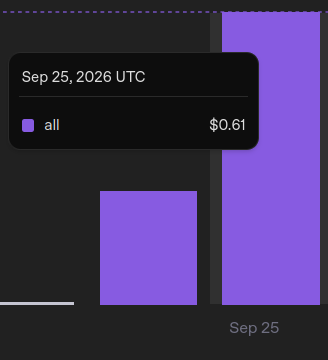

Jev:

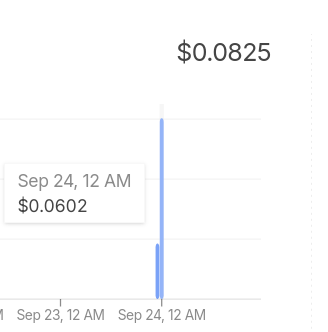

In [11]:
runs = pd.DataFrame([
    {'classifier': 'openai', 'time (min)': round((16 * 60 + 44) / 60, 1), 'cost (USD)': round(9.19 - 8.67, 2)},
    {'classifier': 'jev-noul + jev-choice', 'time (min)': round((68 + 70) / 60, 1), 'cost (USD)': 0.06},
    {'classifier': 'openjev-qwen-choice', 'time (min)': round((7 * 60 + 40) / 60, 1), 'cost (USD)': 0.57},
    {'classifier': 'openjev-deepseek-choice', 'time (min)': round((6 * 60 + 22) / 60, 1), 'cost (USD)': 0.26},
])
runs['threads'] = [classified_threads, 2 * classified_threads, classified_threads, classified_threads]
runs['cost per 1000 threads (USD)'] = (1000 * runs['cost (USD)'] / runs['threads']).round(2)
runs

,classifier,time (min),cost (USD),threads,cost per 1000 threads (USD)
0,openai,16.7,0.52,304,1.71
1,jev-noul + jev-choice,2.3,0.06,608,0.10
2,openjev-qwen-choice,7.7,0.57,304,1.88
3,openjev-deepseek-choice,6.4,0.26,304,0.86


# Previsão de custo e tempo para 30 milhões de e-mails

In [12]:
TARGET_EMAILS = 30_000_000

candidate_threads = round(TARGET_EMAILS * pre_filter['candidate_threads'].sum() / per_list['emails'].sum())
sample_threads = classified_threads

per_thread = pd.DataFrame([
    {'classifier': 'openai', 'time (min)': (16 * 60 + 44) / 60, 'cost (USD)': 9.19 - 8.67},
    {'classifier': 'jev-choice', 'time (min)': 70 / 60, 'cost (USD)': 0.06 / 2},
    {'classifier': 'openjev-qwen-choice', 'time (min)': (7 * 60 + 40) / 60, 'cost (USD)': 0.57},
    {'classifier': 'openjev-deepseek-choice', 'time (min)': (6 * 60 + 22) / 60, 'cost (USD)': 0.26},
]).set_index('classifier') / sample_threads

forecast = pd.DataFrame({
    'candidate threads': candidate_threads,
    'time (hours)': (candidate_threads * per_thread['time (min)'] / 60).round(1),
    'time (days)': (candidate_threads * per_thread['time (min)'] / 60 / 24).round(1),
    'cost (USD)': (candidate_threads * per_thread['cost (USD)']).round(2),
})
forecast

,candidate threads,time (hours),time (days),cost (USD)
classifier,,,,
openai,563931,517.3,21.6,964.62
jev-choice,563931,36.1,1.5,55.65
openjev-qwen-choice,563931,237.0,9.9,1057.37
openjev-deepseek-choice,563931,196.8,8.2,482.31


# Próximos passos

- Conectar os scripts.
- Rodar para outras listas.
- Tratar o erro `max_tokens_exceeded` do Jev, para threads que estouram o contexto.